# 2. Logistic Regression


### What Logistic Regression Is

* Logistic Regression is a **classification algorithm** used when the outcome (target) has only two possible values: **Yes/No, 0/1, True/False**.
* Instead of predicting a continuous number (like Linear Regression), it predicts the **probability** of something belonging to a class.

---

### How It Works

1. It takes the input features (like age, income, or medical test values).
2. It applies a function called the **sigmoid** (an S-shaped curve) that squashes the output into a range between **0 and 1**.
3. The result is interpreted as a **probability**.

   * Example: 0.85 → 85% chance the email is spam.
4. Based on a threshold (commonly 0.5), the model decides the class:

   * ≥ 0.5 → Class 1 (e.g., Spam, Positive, Yes)
   * < 0.5 → Class 0 (e.g., Not Spam, Negative, No)

---

### Why It’s Called “Regression”

* Historically, it comes from regression analysis.
* But instead of predicting a number directly, logistic regression predicts the **log odds** of the outcome — which are then converted into probabilities.

---

### Example Use Cases

* Predicting if a student will **pass or fail** based on study hours.
* Predicting if a transaction is **fraudulent or not**.
* Predicting if a patient’s test is **positive or negative**.

---

👉 In summary:
**Linear Regression = predicts numbers.**
**Logistic Regression = predicts probabilities → which are converted into categories (Yes/No).**



### Working



It models the probability that a given input data point belongs to a particular class.

**Mathematical Intuition**

Instead of fitting a straight line, Logistic Regression uses the sigmoid (or logistic) function to output a probability value between 0 and 1. The function looks like an "S"-shaped curve.

                                                 σ(x)=1 /1+e^-x

The model predicts class "1" if the probability is above a certain threshold (typically 0.5) and class "0" otherwise.

# CODE

In [ ]:
#1
import numpy as np
from sklearn.linear_model import LogisticRegression

# Illustrative data: Hours Studied vs. Pass/Fail (1=Pass, 0=Fail)
X = np.array([[1], [2], [3], [5], [6], [7], [9], [10],[4],[1.5], [4], [5]])
y = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1])

# Create and train the model
model = LogisticRegression()
model.fit(X, y)
score = model.score(X,y) # metrics used to evaluate the model is accuracy
print("model score:", score)

# Predict outcome for a student who studied 4 hours
hours_studied = np.array([[4]])
prediction_proba = model.predict_proba(hours_studied)
print(f"Probability of passing after studying {hours_studied[0][0]} hours: {prediction_proba[0][1]:.2f}")

model score: 0.9166666666666666
Probability of passing after studying 4 hours: 0.53


In [16]:
hours_studied=np.array([[4.5]])
predicttion=model.predict(hours_studied)
print(f"Prediction: {predicttion[0]}") 


Prediction: 1


#### 2

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Create Example Data
# -----------------------------------
# Hours studied,coffe vs Pass(1)/Fail(0)

X = np.array([[1,3], [2,0], [3,3], [4,0], [5,2], [6,1], [7,3], [8,2], [9,5], [10,10]])
y = np.array([0, 0, 1, 0, 1, 0, 1, 1, 1, 1])

# -----------------------------------
# 2. Train Logistic Regression Model
# -----------------------------------

model = LogisticRegression()
model.fit(X, y)

# -----------------------------------
# 3. See learned parameters
# -----------------------------------

print("Weight (w):", model.coef_)
print("Bias (b):", model.intercept_)

# Equation form:
# z = w*x + b

# -----------------------------------
# 4. Predict for a new student
# -----------------------------------

hours_studied = np.array([[4,3]])

probability = model.predict_proba(hours_studied)
prediction = model.predict(hours_studied)

print(f"\nFor {hours_studied[0][0]} hours studied + {hours_studied[0][1]} Coffee:")
print("Probability of Fail (0):", probability[0][0])
print("Probability of Pass (1):", probability[0][1])
print("Final Prediction:", prediction[0])

# -----------------------------------
# 5. Accuracy on training data
# -----------------------------------

accuracy = model.score(X, y)
print("\nModel Accuracy:", accuracy)


Weight (w): [[0.56943509 0.9963231 ]]
Bias (b): [-4.36097889]

For 4 hours studied + 3 Coffee:
Probability of Fail (0): 0.28787425068190986
Probability of Pass (1): 0.7121257493180901
Final Prediction: 1

Model Accuracy: 0.9


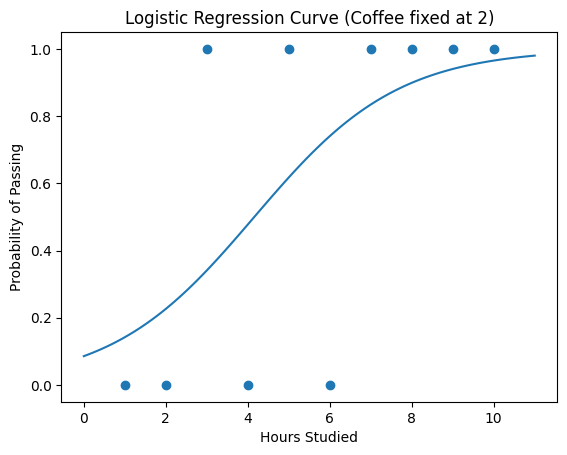

In [21]:
# -----------------------------------
# 6. Visualize Effect of Hours (Coffee fixed)
# -----------------------------------

hours_range = np.linspace(0, 11, 100)
coffee_fixed = 2  # keep coffee constant

X_test = np.column_stack((hours_range, 
                          np.full(100, coffee_fixed)))

y_prob = model.predict_proba(X_test)[:, 1]

plt.scatter(X[:, 0], y)  # plotting hours vs result
plt.plot(hours_range, y_prob)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Passing")
plt.title("Logistic Regression Curve (Coffee fixed at 2)")
plt.show()

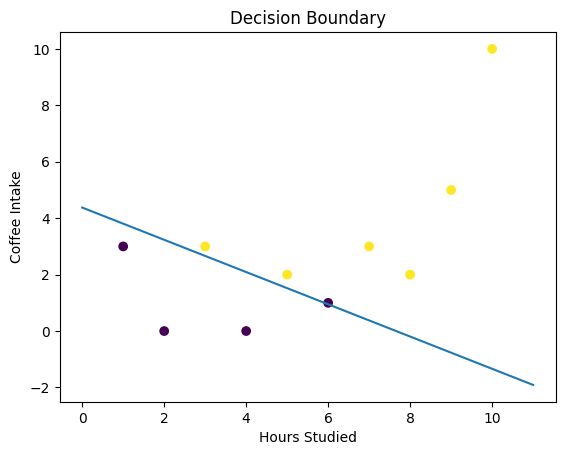

In [22]:
# -----------------------------------
# 6. Plot Decision Boundary
# -----------------------------------

w1 = model.coef_[0][0]
w2 = model.coef_[0][1]
b = model.intercept_[0]

# Plot original data
plt.scatter(X[:, 0], X[:, 1], c=y)

# Create hours range
hours_range = np.linspace(0, 11, 100)

# Calculate coffee boundary
coffee_boundary = -(w1 * hours_range + b) / w2

plt.plot(hours_range, coffee_boundary)

plt.xlabel("Hours Studied")
plt.ylabel("Coffee Intake")
plt.title("Decision Boundary")
plt.show()

In [1]:
# 1. Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer  # example dataset

# 2. Load example binary classification data
data = load_breast_cancer()  # features + target 
X = data.data               # shape: (n_samples, n_features)
y = data.target             # 0 or 1

# 3. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  

# 4. (Optional but common) feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  

# 5. Define and train the logistic regression model
model = LogisticRegression(
    penalty="l2",      # L2 regularization
    C=1.0,             # inverse of regularization strength
    solver="lbfgs",    # good default for small/medium data
    max_iter=1000,     # increase if convergence warning
    random_state=42
)
model.fit(X_train, y_train)  

# 6. Predictions
y_pred = model.predict(X_test)          # class labels 0/1 
y_proba = model.predict_proba(X_test)   # probabilities for each class 

# 7. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))        
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))  
print("Classification report:\n", classification_report(y_test, y_pred))  


Accuracy: 0.9736842105263158
Confusion matrix:
 [[41  2]
 [ 1 70]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [3]:
a=model.score(y_test,y_pred)

ValueError: Expected 2D array, got 1D array instead:
array=[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.